In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pyshtools as pysh
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
import os 
from meshplot import plot, subplot 
import anndata as ad
import pandas as pd
import json

import igl 
from scipy.sparse.linalg import eigsh
from scipy import sparse 
from tqdm import tqdm
from sklearn.neighbors import NearestNeighbors

from scipy.special import digamma, gamma
from collections import defaultdict

In [2]:
import importlib
import src.meshharm
import src.fatemarkers
importlib.reload(src.meshharm)
importlib.reload(src.fatemarkers)


from src import utils 
from src.fatemarkers import FateMarkers
from src.ksg_estimators import KSGEstimator

In [2]:
# path = 'Data/20260211/'
path = 'Data/20260224'

with open(f"{path}/config.json", 'r') as f:
    cfg = json.load(f)
timepoints  = cfg['timepoints']
zarr_names  = cfg['zarr_names']
wells       = cfg['wells']
rounds      = cfg['rounds']
times_dic   = cfg['times_dic'] 
annotation_names = cfg['annotation_names']

In [3]:
# state an order 
correct_order = list(annotation_names.keys())

In [4]:
# load the hks vocabs 
res = np.load('sim/vocab_new.npz', allow_pickle=True)
vocab_hks = res['vocab']
sigma_hks = res['sigma']
scaler_hks = res['scaler'].item() 
ts = res['ts']

def complexity(m): 
    errs = [] 
    ls = np.arange(1, 10)
    for l in ls:
        err = m.compute_recon_quality(lmax=l) 
        errs.append(err)
    return np.array(errs) 

def load_bof(save_path, ts): 
    m = FateMarkers()
    m.load_results(save_path)
    frac_diff = m.compute_recon_quality()
    hks = m.compute_hks_for_new_times(ts, coeffs=False)
    hks_scaled = scaler_hks.transform(hks / np.mean(hks, axis=0) - 1)
    dist = np.linalg.norm(hks_scaled[:, np.newaxis, :]- vocab_hks[np.newaxis, :, :], axis=2)
    encoding = np.exp(-dist**2 / (2 * sigma_hks**2))
    coeffs_hks = m.modes.T @ (m.mass_matrix @ encoding)
    indices = [m.field_names.index(annotation_names[name]) for name in correct_order]

    c = complexity(m)

    return m.coeffs_fm[:, indices], coeffs_hks, frac_diff, m.area, c 

def load(save_path, ts):
    m = FateMarkers()
    m.load_results(save_path)
    frac = m.compute_recon_quality()
    hks_coeffs = m.compute_hks_for_new_times(ts) 
    indices = [m.field_names.index(annotation_names[name]) for name in correct_order] 
    return m.coeffs_fm[:, indices], hks_coeffs, frac, m.area 

In [9]:
coeffs_hks = [] 
coeffs_fm = [] 
times = [] 
fracs = []
areas = [] 
ids = [] 
complexities = [] 

for timepoint in timepoints:
    zarr_name = zarr_names[timepoint]
    for well_name in wells[timepoint]:
        round_name = rounds[timepoint]
        file_path = f"{path}/fractal_output/{timepoint}/{zarr_name}/{well_name[0]}/{well_name[1:]}/{round_name}/"
        labels = np.load(f"{file_path}/fm_data/good_labels.npy")
        for label in tqdm(labels):
            save_path = f"{file_path}/fm_data/{label}"
            if os.path.exists(save_path + '_coeffs.npz'):
                c1, c2, frac, A, c = load_bof(save_path, ts)
                coeffs_fm.append(c1)
                coeffs_hks.append(c2)
                times.append(timepoint[3:6])
                fracs.append(frac)
                areas.append(A)
                complexities.append(c)
                ids.append(f"{timepoint}_{well_name}_{label}") 

  0%|          | 0/93 [00:00<?, ?it/s]

100%|██████████| 59/59 [00:05<00:00, 10.05it/s]


In [10]:
threshold = np.percentile(fracs, 95)
recon_mask = (np.array(fracs) < threshold) 
filtered_times = np.array(times)[recon_mask]
filtered_hks = np.array(coeffs_hks)[recon_mask]
filtered_areas = np.array(areas)[recon_mask]
coeffs_fm_filtered = np.array(coeffs_fm)[recon_mask]
filtered_complexities = np.array(complexities)[recon_mask]
filtered_ids = np.array(ids)[recon_mask]

In [11]:
num_degree = int(np.sqrt(filtered_hks.shape[1]))
hks_power_spectrum = np.zeros((filtered_hks.shape[0], num_degree, filtered_hks.shape[2]))
fm_power_spectrum = np.zeros((coeffs_fm_filtered.shape[0], num_degree, coeffs_fm_filtered.shape[2])) 

for n in range(num_degree):
    start_idx = n**2
    end_idx = (n+1)**2
    # Sum of squared coefficients between l = n^2 and (n+1)^2
    hks_power_spectrum[:, n, :] = np.sum(filtered_hks[:, start_idx:end_idx, :]**2, axis=1)
    fm_power_spectrum[:, n, :] = np.sum(coeffs_fm_filtered[:, start_idx:end_idx, :]**2, axis=1)

print(fm_power_spectrum.shape)

(2671, 15, 10)


In [12]:
def normalise_fm(fm): 
    # Only compute upper quantile amongst non-zero values
    nonzero_mask = fm[:, 0, :] > 0 # when the mean is nonzero 
    upper_quantile = np.zeros((fm.shape[-1]))
    for col in range(fm.shape[-1]):
        nonzero_values = fm[nonzero_mask[:, col], 0, col]
        if len(nonzero_values) > 0:
            upper_quantile[col] = np.max(nonzero_values)
        else:
            upper_quantile[col] = 1  # avoid division by zero
    mean_rm = fm / upper_quantile[np.newaxis, np.newaxis, :]
    return (mean_rm)

In [13]:
fm_power_spectrum = normalise_fm(fm_power_spectrum)
hks_power_spectrum /= np.max(hks_power_spectrum, axis=(0,1), keepdims=True)  # Normalize HKS by its maximum value across all samples and degrees
coeffs = np.concatenate([fm_power_spectrum, hks_power_spectrum], axis=-1)

hks_names = [f'hks-{i}' for i in range(hks_power_spectrum.shape[-1])]
names = correct_order + hks_names 
print(names)

['lgr', 'chroma', 'cycd', 'muc', 'aldob', 'gluc', 'cyca', 'agr', 'sero', 'lyz', 'hks-0', 'hks-1', 'hks-2', 'hks-3', 'hks-4', 'hks-5', 'hks-6', 'hks-7']


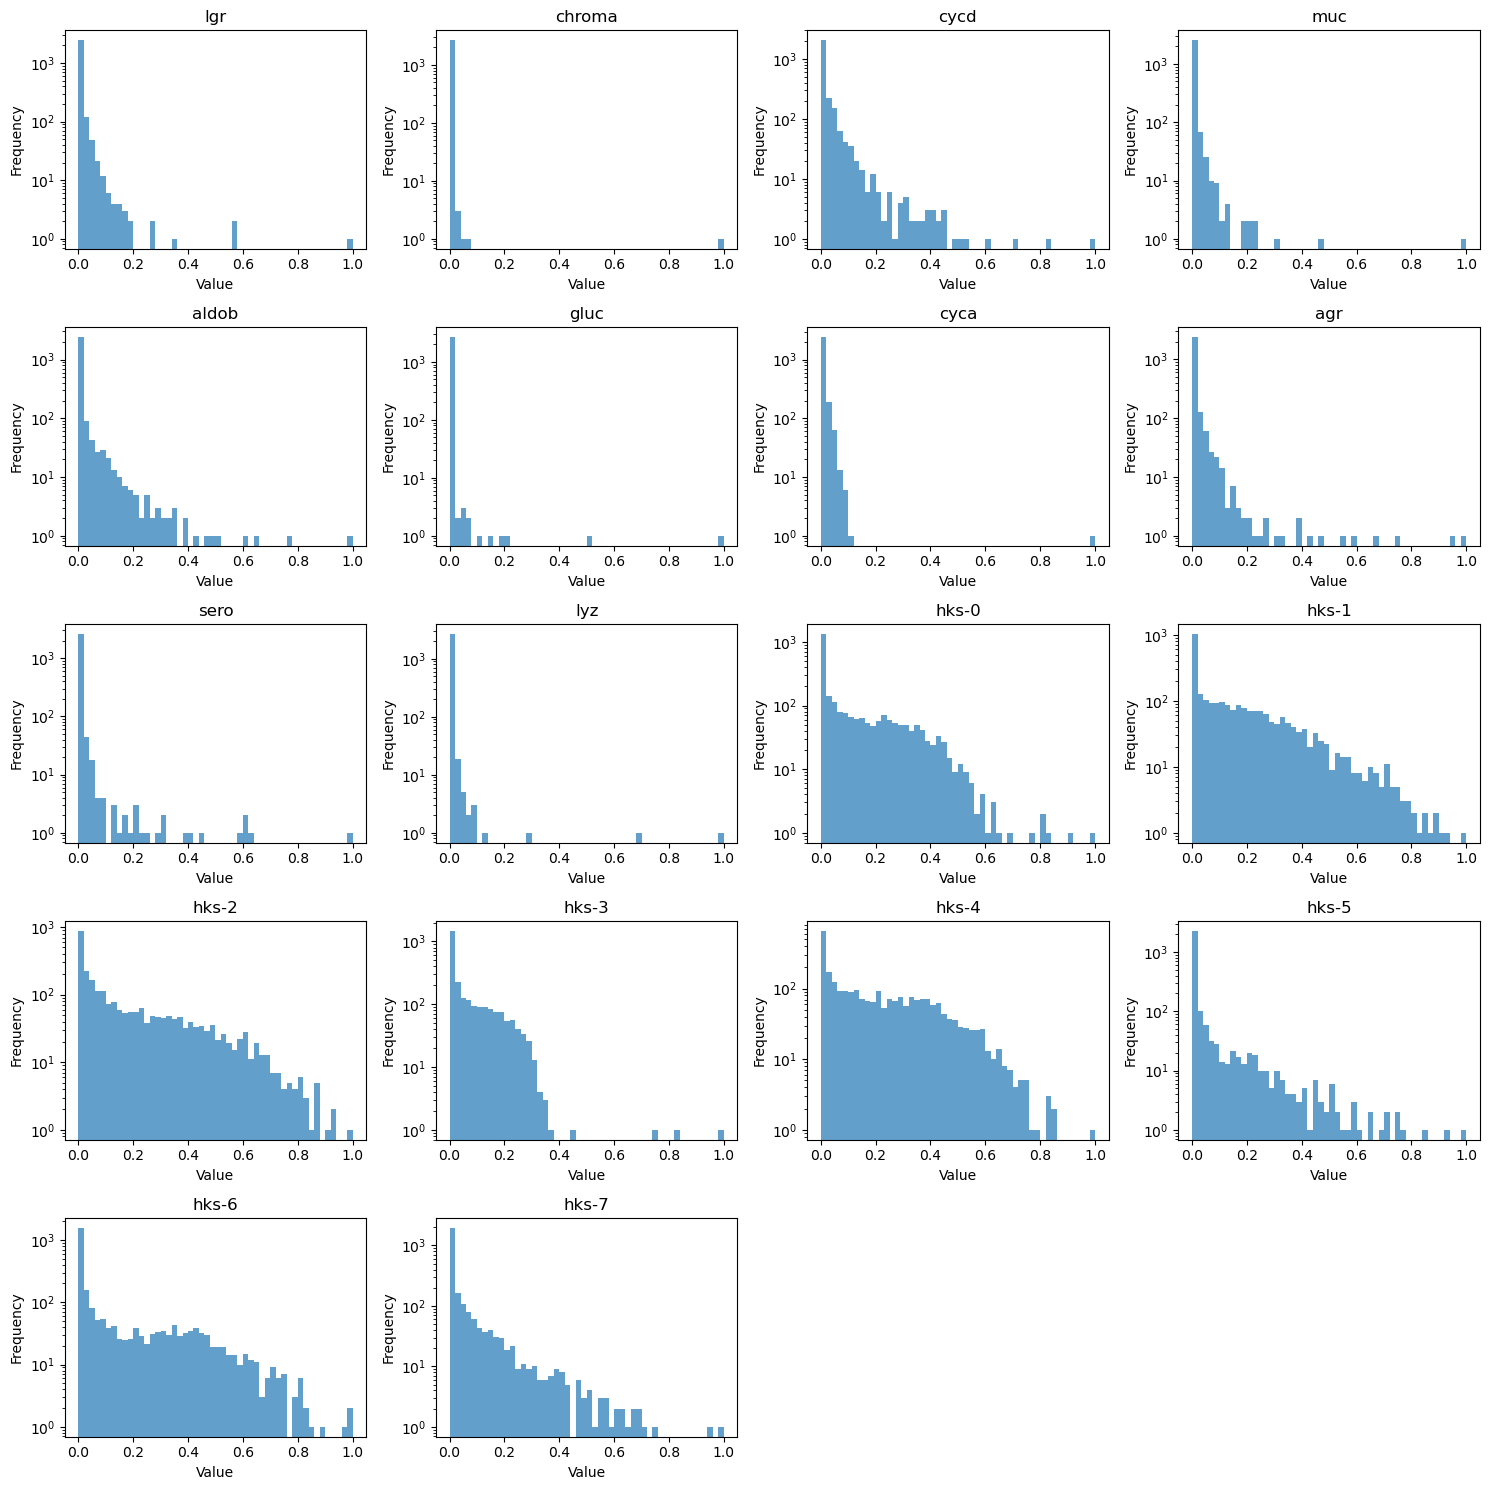

In [14]:
import matplotlib.pyplot as plt

num_features = coeffs.shape[-1]
ncols = 4
nrows = (num_features + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(15, 3 * nrows))
axes = axes.flatten()

for i in range(num_features):
    axes[i].hist(coeffs[:, 0, i], bins=50, alpha=0.7)
    axes[i].set_title(names[i])
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].set_yscale('log')  # Use logarithmic scale for better visibility

# Hide unused subplots
for j in range(num_features, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [16]:
import pandas as pd 

df = pd.read_csv('Data/cell_types_norm_neg.csv')

# reorder df according to filtered_ids 
df = df.set_index('label_uid').reindex(filtered_ids).reset_index()
print(df.columns[-10:-1])
percentages = df[df.columns[-10:-1]].values

assert np.all(df['label_uid'] == filtered_ids)

np.savetxt('Data/organoid_uid_list.txt', filtered_ids, fmt='%s')

Index(['LGR.cnt_exclusive', 'CHROMA.cnt_exclusive', 'TA.cnt_exclusive',
       'MUC.cnt_exclusive', 'ALDOB.cnt_exclusive', 'GLUC.cnt_exclusive',
       'AGR.cnt_exclusive', 'SERO.cnt_exclusive', 'LYZ.cnt_exclusive'],
      dtype='object')


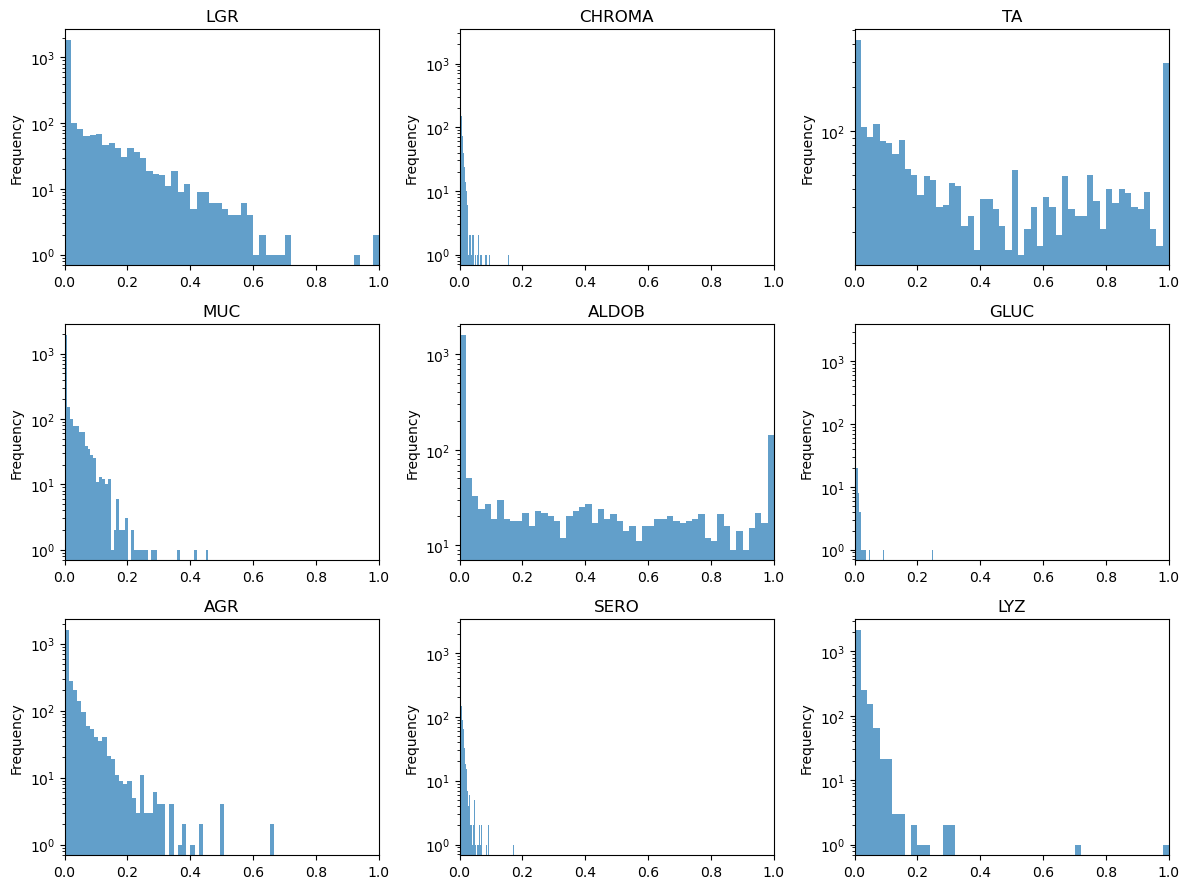

In [17]:
col_names = [c.split('.')[0] for c in df.columns[-10:-1]]
ncols = 3
nrows = (percentages.shape[1] + ncols - 1) // ncols

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 3 * nrows))
axes = axes.flatten()

for i in range(percentages.shape[1]):
    axes[i].hist(percentages[:, i], bins=50, alpha=0.7)
    axes[i].set_title(col_names[i])
    axes[i].set_ylabel('Frequency')
    axes[i].set_yscale('log')
    axes[i].set_xlim([0, 1])

for j in range(percentages.shape[1], len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

(2671, 9)


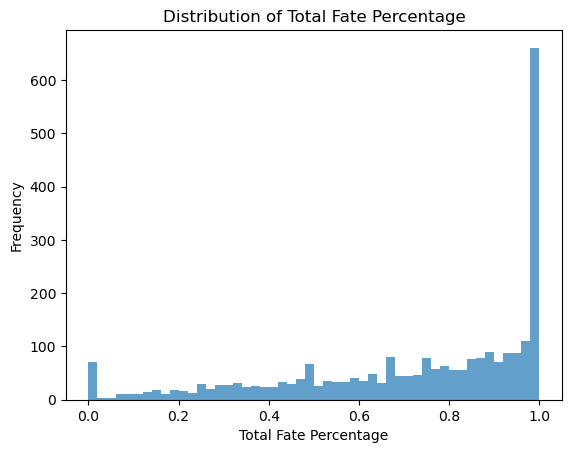

False
False


In [ ]:
remainder = 1 - percentages.sum(axis=1, keepdims=True)
percentages_full = np.hstack([percentages, remainder])

In [34]:
np.savez('sim/coembedding_raw_value.npz', 
         ids=filtered_ids,
         time=filtered_times,
         hks = hks_power_spectrum, 
         areas=filtered_areas,
         complexities=filtered_complexities, 
         percentages=percentages_full, 
         fate_names=col_names, 
)

In [350]:
file = np.load('sim/coembedding_raw_value.npz', allow_pickle=True)
filtered_ids = file['ids']
filtered_times = file['time']
hks_power_spectrum = file['hks']
filtered_areas = file['areas']
filtered_complexities = file['complexities']
percentages_full = file['percentages']
fate_names = file['fate_names']

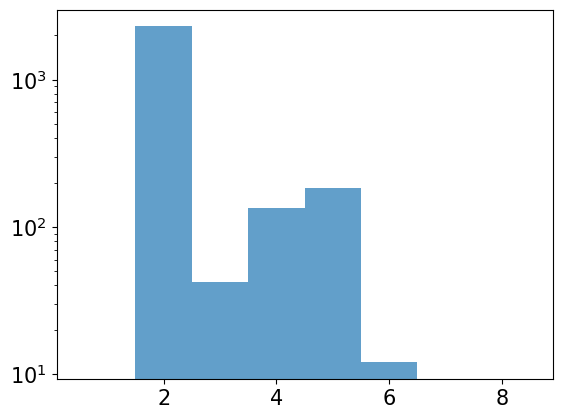

In [351]:
l_cross_values = [] 
threshold = 0.015
for errs in filtered_complexities: 
    # interpolate to find the l value where err crosses the threshold
    if errs[-1] > threshold:
        l_cross_values.append(9)
    else: 
        l_cross = np.interp(threshold, errs[::-1], np.arange(9, 0, -1))
        l_cross_values.append(l_cross)
l_cross_values = np.array(l_cross_values)

plt.hist(l_cross_values, bins=np.arange(0.5, 9.5, 1), alpha=0.7)  
plt.yscale('log')
plt.show()  

In [352]:
# subsample by complexity 
bins = [1, 3, 7]

# count how many samples fall into each bin
bin_counts = np.histogram(l_cross_values, bins=bins)[0]
print("Bin counts:", bin_counts)

# randomly subsample from each bin to have at most n samples per bin 
ns = [500, bin_counts[1]]
subsampled_indices = []
for i in range(len(bins)-1):
    bin_mask = (l_cross_values >= bins[i]) & (l_cross_values < bins[i+1])
    bin_indices = np.where(bin_mask)[0]
    if len(bin_indices) > ns[i]:
        subsampled_indices.extend(np.random.choice(bin_indices, ns[i], replace=False))
    else: 
        subsampled_indices.extend(bin_indices)
subsampled_indices = np.array(subsampled_indices)
print(f"Subsampled to {len(subsampled_indices)} samples")


percentages_full = percentages_full[subsampled_indices]
hks_power_spectrum = hks_power_spectrum[subsampled_indices]
filtered_times = filtered_times[subsampled_indices]
filtered_areas = filtered_areas[subsampled_indices]
filtered_ids = filtered_ids[subsampled_indices]
l_cross_values = l_cross_values[subsampled_indices]

Bin counts: [2321  350]
Subsampled to 850 samples


In [328]:
# subsample by timepoint

print("Unique timepoints:", np.unique(filtered_times))

# count how many samples fall into each timepoint
timepoint_counts = pd.Series(filtered_times).value_counts()
print("Timepoint counts:", timepoint_counts)

Unique timepoints: ['1p5' '2' '2p5' '3' '3p5' '4' '4p5']
Timepoint counts: 4p5    547
3      463
1p5    378
2p5    364
4      337
3p5    303
2      279
Name: count, dtype: int64


In [353]:
def ilr_transform(X, eps=1e-6):
    X = np.asarray(X, dtype=float)
    X = X / X.sum(axis=1, keepdims=True)
    # multiplicative zero replacement: preserve sum=1
    zero_mask = X <= 0
    n_zeros = zero_mask.sum(axis=1, keepdims=True)
    X = np.where(zero_mask, eps, X * (1 - eps * n_zeros))
    # CLR
    log_x = np.log(X)
    clr = log_x - log_x.mean(axis=1, keepdims=True)
    # Helmert basis (D, D-1)
    D = X.shape[1]
    j = np.arange(1, D)
    a = 1.0 / np.sqrt(j * (j + 1))
    V = np.zeros((D, D - 1))
    for col, (jj, aa) in enumerate(zip(j, a)):
        V[:jj, col] = aa
        V[jj, col] = -jj * aa
    return clr @ V

percentages_ilr = ilr_transform(percentages_full)
print(percentages_ilr.shape)  # (N, D-1)

(850, 9)


In [354]:
method = 'umap'  # 'tsne' | 'umap' | 'phate'

if method == 'tsne':
    from sklearn.manifold import TSNE
    percentages_emb = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(percentages_ilr)

elif method == 'umap':
    import umap
    percentages_emb = umap.UMAP(n_components=2, random_state=42, n_neighbors=50, min_dist=1).fit_transform(percentages_ilr)

elif method == 'phate':
    import phate
    temp = percentages_ilr + np.random.normal(0, 1e-5, size=percentages_ilr.shape)  # add small noise for stability
    percentages_emb = phate.PHATE(n_components=2, random_state=42, knn=30, t=30).fit_transform(temp)
elif method == 'pca':
    from sklearn.decomposition import PCA
    percentages_emb = PCA(n_components=2).fit_transform(percentages_ilr)

/opt/homebrew/anaconda3/envs/scmpx/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


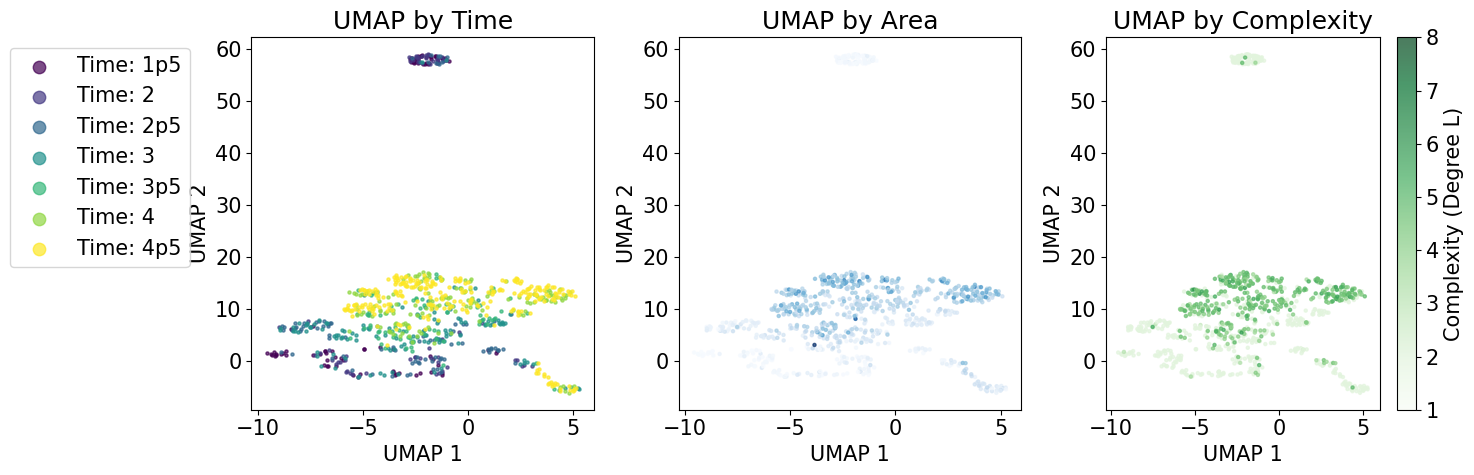

In [355]:
# Plotting
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
unique_times = np.unique(filtered_times)
point_size = 5

cmap_time = plt.get_cmap('viridis')
for i, t in enumerate(unique_times):
    mask = filtered_times == t
    color = cmap_time(i / (len(unique_times) - 1))
    axes[0].scatter(percentages_emb[mask, 0], percentages_emb[mask, 1], color=color, alpha=0.7, s=point_size, label=f"Time: {t}")
axes[0].set_title(f'{method.upper()} by Time')
axes[0].set_xlabel(f'{method.upper()} 1')
axes[0].set_ylabel(f'{method.upper()} 2')
axes[0].legend(bbox_to_anchor=(-0.15, 1), loc='upper right', markerscale=4)

axes[1].scatter(percentages_emb[:, 0], percentages_emb[:, 1], c=filtered_areas, cmap='Blues', alpha=0.7, s=point_size)
axes[1].set_title(f'{method.upper()} by Area')
axes[1].set_xlabel(f'{method.upper()} 1')
axes[1].set_ylabel(f'{method.upper()} 2')   

sc_tsne_complex = axes[-1].scatter(percentages_emb[:, 0], percentages_emb[:, 1], c=l_cross_values, cmap='Greens', alpha=0.7, s=point_size, vmin=1, vmax=8)
axes[-1].set_title(f'{method.upper()} by Complexity')
axes[-1].set_xlabel(f'{method.upper()} 1')
axes[-1].set_ylabel(f'{method.upper()} 2')
fig.colorbar(sc_tsne_complex, ax=axes[-1], label='Complexity (Degree L)')

plt.tight_layout()
plt.show()

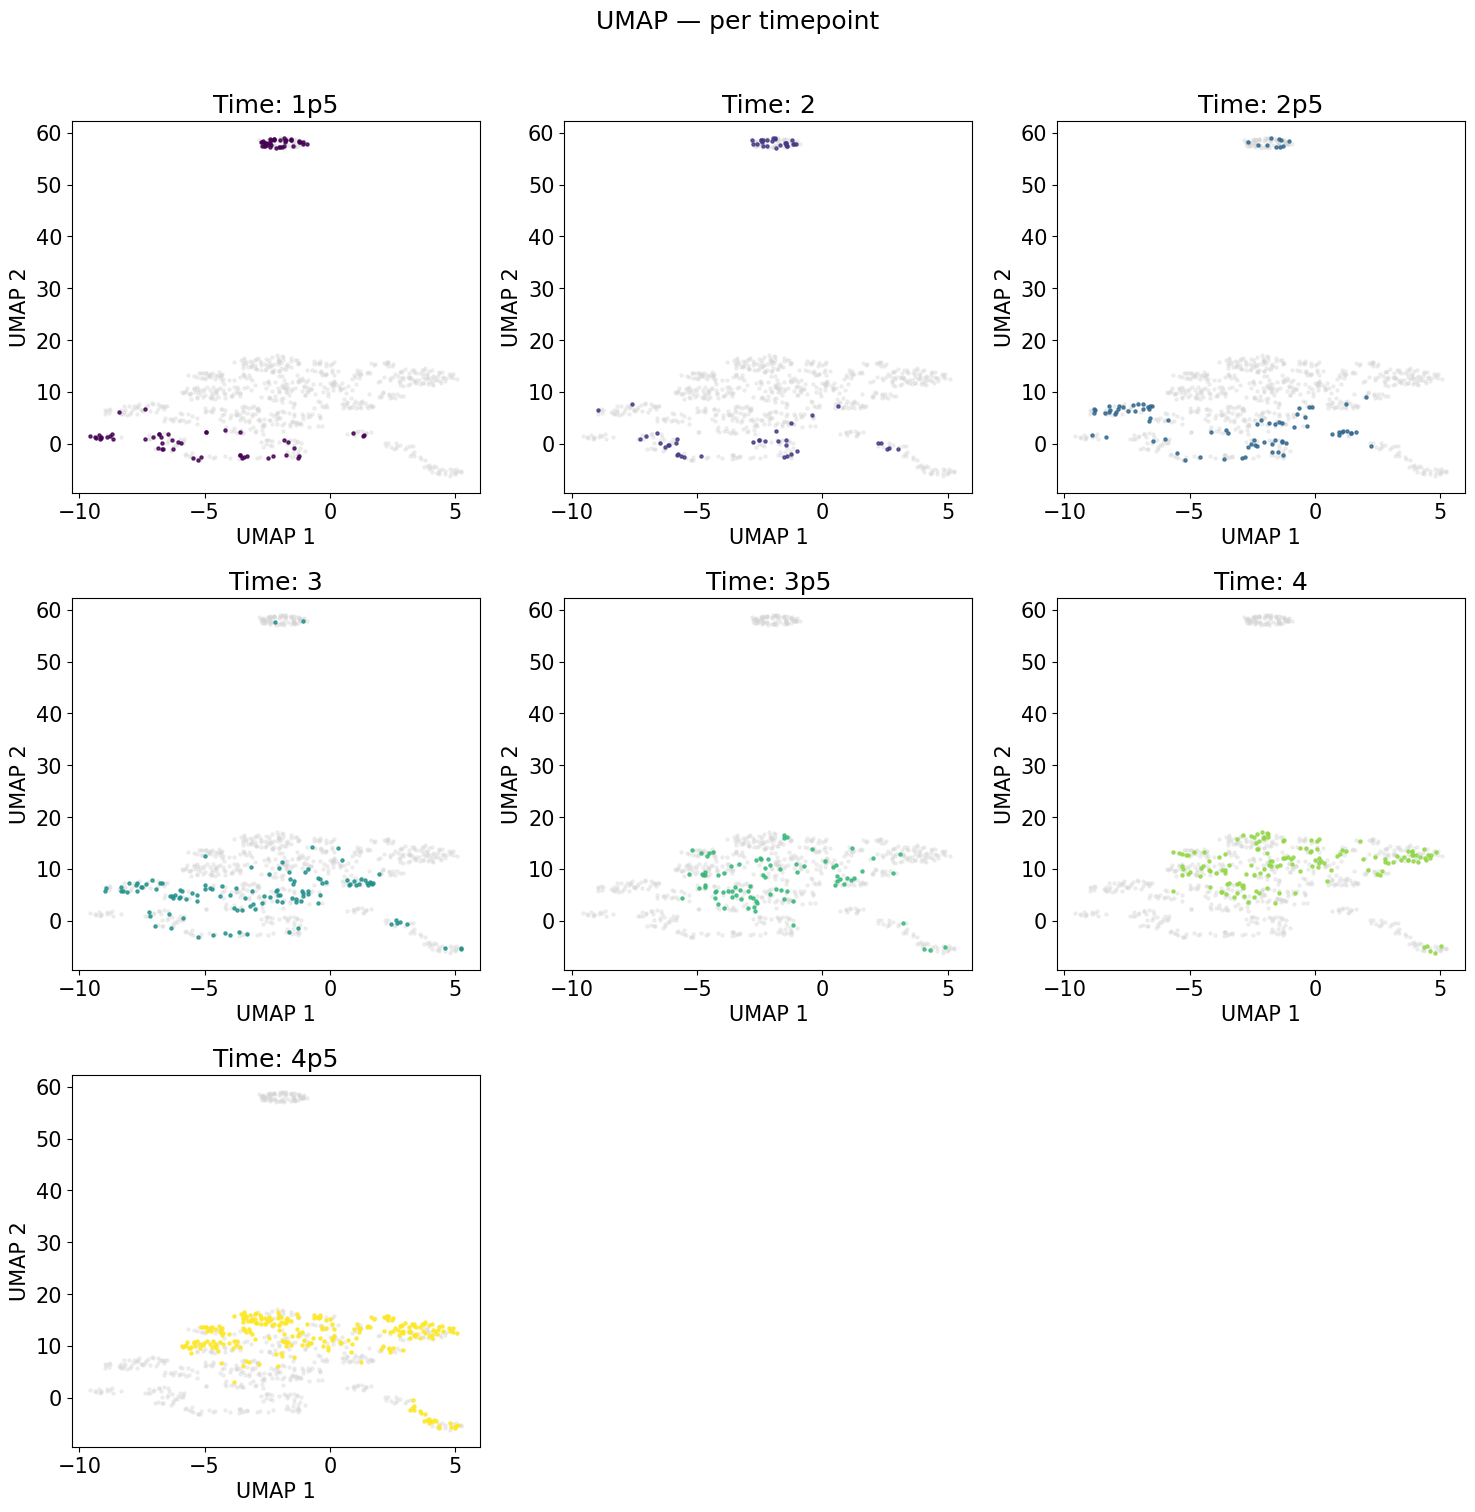

In [356]:
unique_times = np.unique(filtered_times)
ncols = 3
nrows = (len(unique_times) + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = axes.flatten()

cmap_time = plt.get_cmap('viridis')
for i, t in enumerate(unique_times):
    mask = filtered_times == t
    color = cmap_time(i / (len(unique_times) - 1))
    axes[i].scatter(percentages_emb[~mask, 0], percentages_emb[~mask, 1], color='lightgrey', alpha=0.3, s=point_size)
    axes[i].scatter(percentages_emb[mask, 0], percentages_emb[mask, 1], color=color, alpha=0.8, s=point_size)
    axes[i].set_title(f'Time: {t}')
    axes[i].set_xlabel(f'{method.upper()} 1')
    axes[i].set_ylabel(f'{method.upper()} 2')

for j in range(len(unique_times), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'{method.upper()} — per timepoint', y=1.01)
plt.tight_layout()
plt.show()

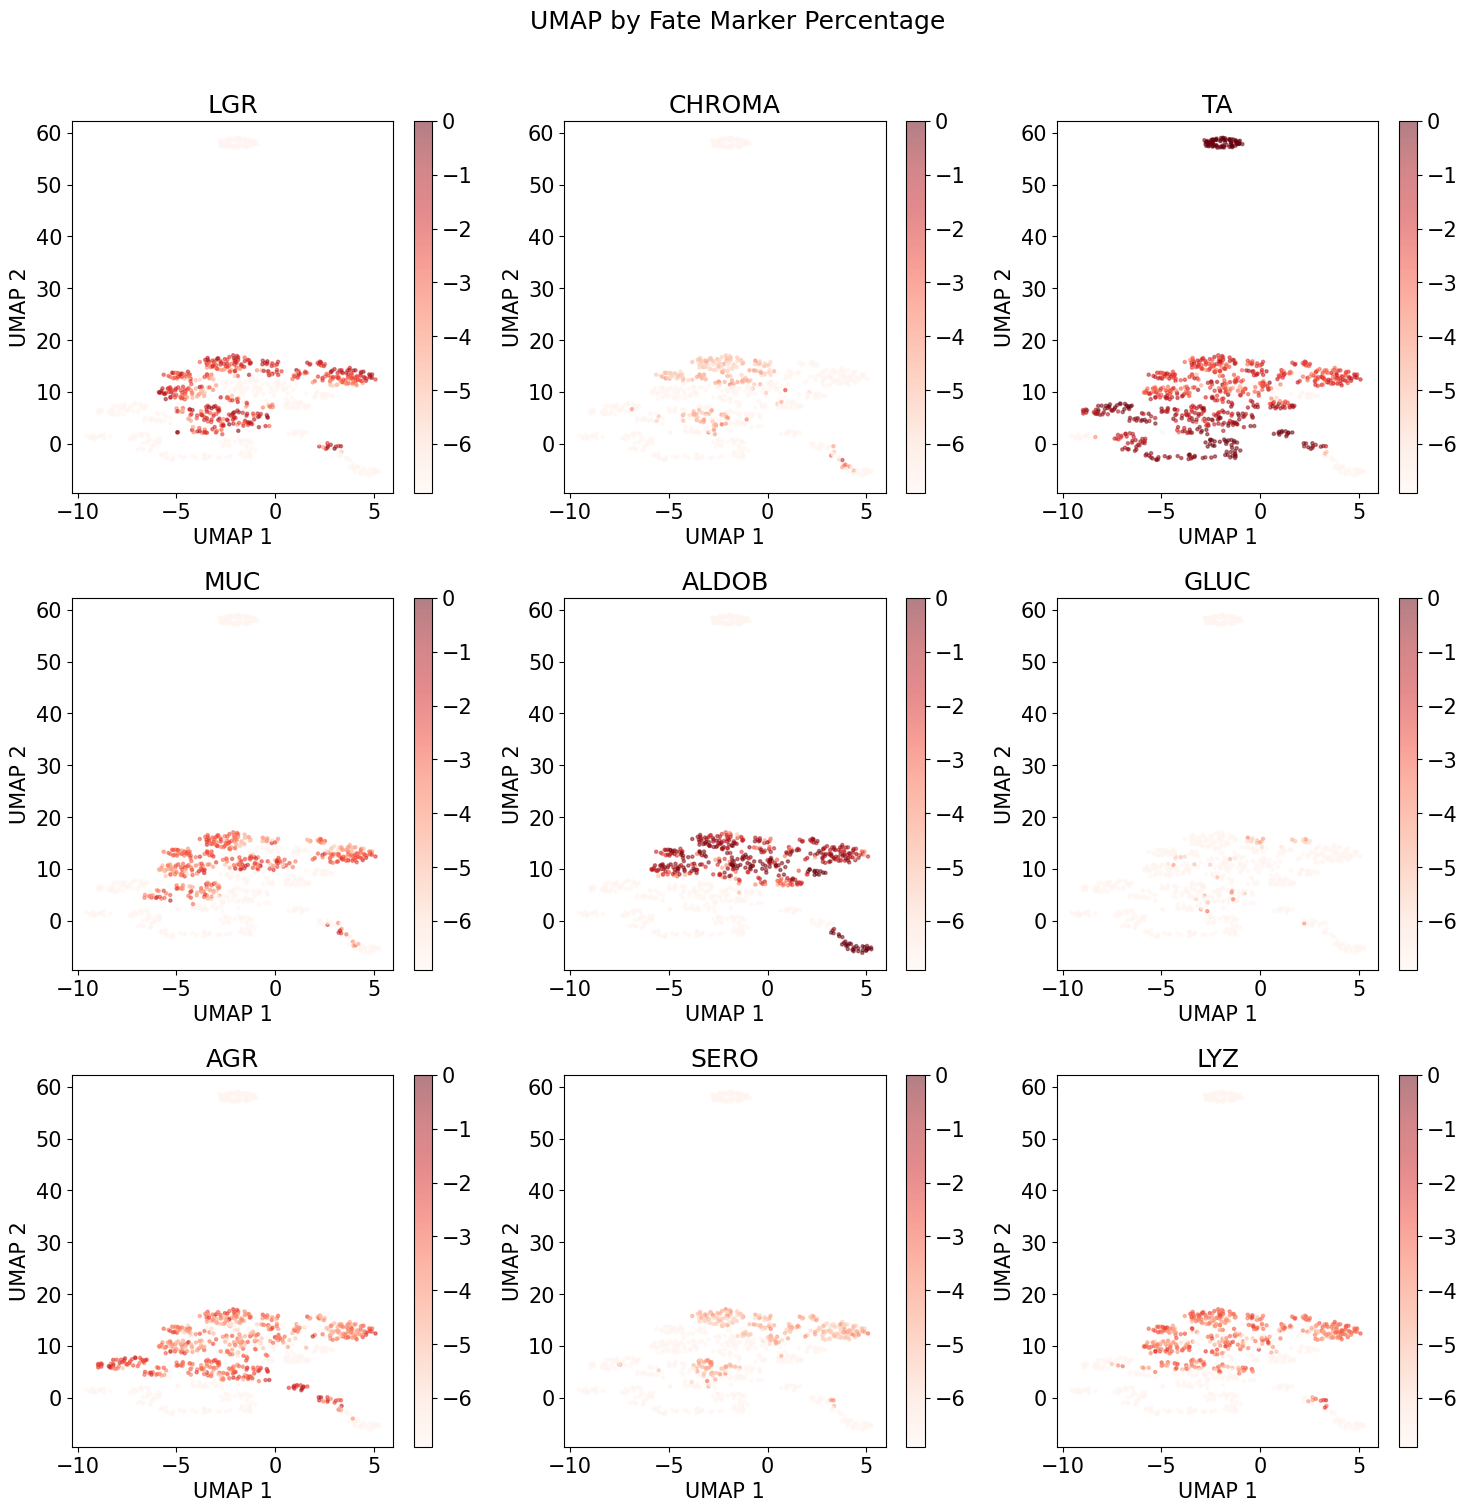

In [357]:
col_names = fate_names 
ncols = 3
nrows = (percentages_ilr.shape[1] + ncols - 1) // ncols

log_perc = np.log(percentages_full + 1e-3)
vmin, vmax = log_perc.min(), log_perc.max()

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = axes.flatten()

for i in range(percentages_ilr.shape[1]):
    sc = axes[i].scatter(percentages_emb[:, 0], percentages_emb[:, 1], c=log_perc[:, i],
                         cmap='Reds', alpha=0.5, s=point_size, vmin=vmin, vmax=vmax)
    axes[i].set_title(col_names[i])
    axes[i].set_xlabel(f'{method.upper()} 1')
    axes[i].set_ylabel(f'{method.upper()} 2')
    fig.colorbar(sc, ax=axes[i])

for j in range(percentages_ilr.shape[1], len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(f'{method.upper()} by Fate Marker Percentage', y=1.01)
plt.tight_layout()
plt.show()

In [358]:
## compute all pairwise distances between samples 

weights = np.sqrt(np.array([2, 2, 1, 0.1, 1, 2, 0.1, 2]))
hks_power_spectrum_scaled = hks_power_spectrum * weights[np.newaxis, np.newaxis, :]
hks_reshaped = hks_power_spectrum_scaled.reshape(hks_power_spectrum_scaled.shape[0], -1)

# randomly select 1000 pairs of samples to compute distances
num_samples = hks_reshaped.shape[0]
num_pairs = 5000
sample_indices = np.random.choice(num_samples, size=(num_pairs, 2), replace=True)

hks_dist = np.linalg.norm(hks_reshaped[sample_indices[:, 0]]- hks_reshaped[sample_indices[:, 1]], axis=1)
perc_dist = np.linalg.norm(percentages_ilr[sample_indices[:, 0]]- percentages_ilr[sample_indices[:, 1]], axis=1)

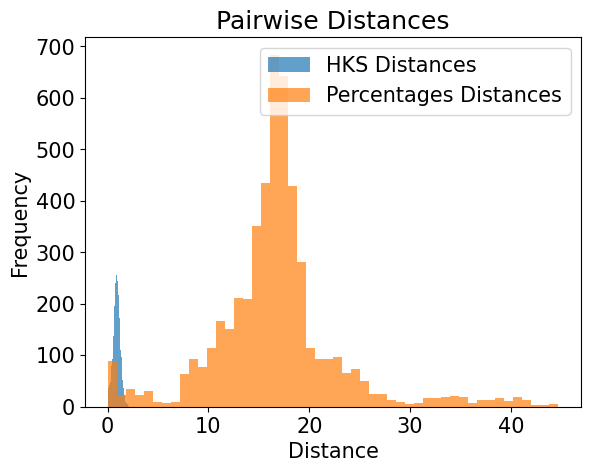

Mean HKS Distance: 0.8973
Mean Percentages Distance: 16.6905


In [359]:

plt.hist(hks_dist.flatten(), bins=50, alpha=0.7, label='HKS Distances')
plt.hist(perc_dist.flatten(), bins=50, alpha=0.7, label='Percentages Distances')
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Pairwise Distances')
plt.legend()
plt.show()

mean_hks_dist = np.mean(hks_dist)
mean_perc_dist = np.mean(perc_dist)

print(f"Mean HKS Distance: {mean_hks_dist:.4f}")
print(f"Mean Percentages Distance: {mean_perc_dist:.4f}")

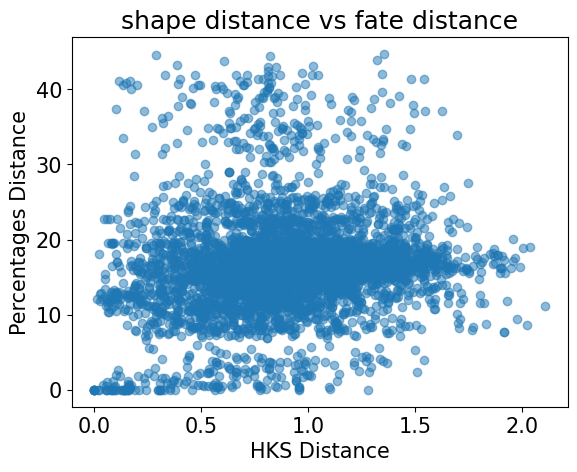

In [360]:
plt.plot(hks_dist.flatten(), perc_dist.flatten(), 'o', alpha=0.5)
plt.xlabel('HKS Distance')
plt.ylabel('Percentages Distance')
plt.title('shape distance vs fate distance')
plt.show()  

In [361]:
hks_normalised = hks_power_spectrum / mean_hks_dist
percentages_normalised = percentages_ilr / mean_perc_dist

X scores: (850, 2), Y scores: (850, 2)


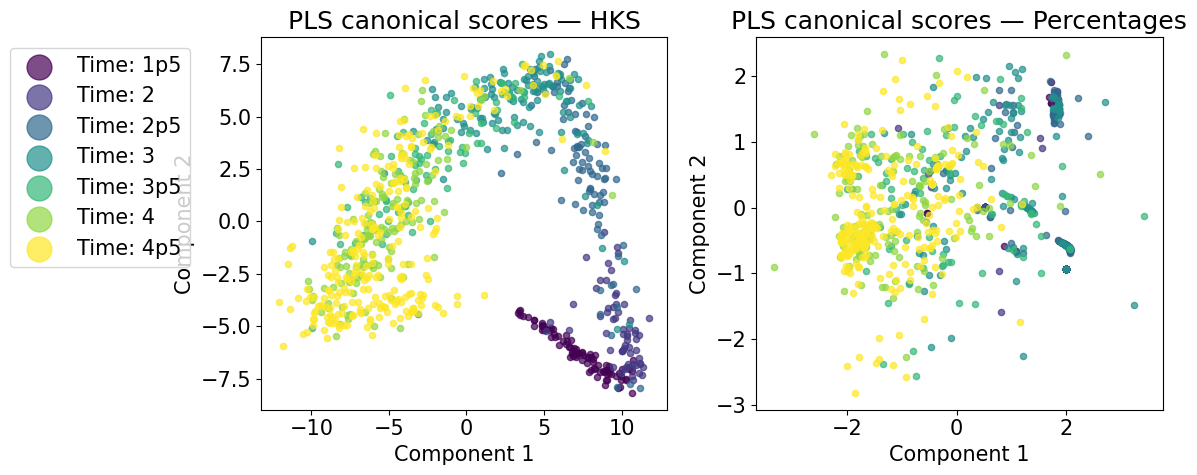

In [362]:
from sklearn.cross_decomposition import PLSCanonical

X_pls = hks_normalised.reshape(hks_normalised.shape[0], -1)
Y_pls = percentages_normalised

pls = PLSCanonical(n_components=2, max_iter=1000)
pls.fit(X_pls, Y_pls)
X_c, Y_c = pls.transform(X_pls, Y_pls)
print(f"X scores: {X_c.shape}, Y scores: {Y_c.shape}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, scores, label in zip(axes, [X_c, Y_c], ['HKS', 'Percentages']):
    cmap_time = plt.get_cmap('viridis')
    for i, t in enumerate(np.unique(filtered_times)):
        mask = filtered_times == t
        ax.scatter(scores[mask, 0], scores[mask, 1], color=cmap_time(i / (len(np.unique(filtered_times)) - 1)),
                   alpha=0.7, s=20, label=f"Time: {t}")
    ax.set_title(f'PLS canonical scores — {label}')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
axes[0].legend(bbox_to_anchor=(-0.15, 1), loc='upper right', markerscale=4)
plt.tight_layout()
plt.show()




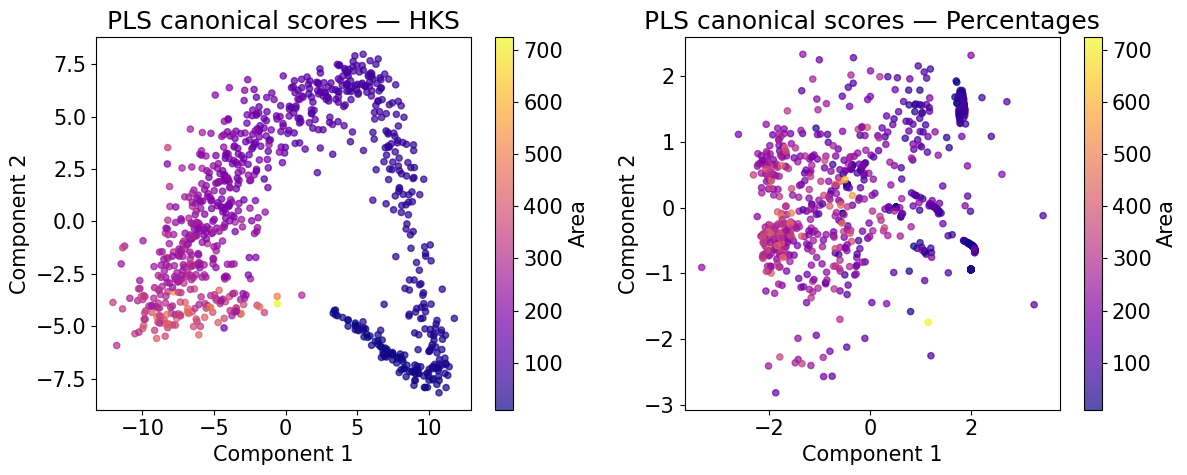

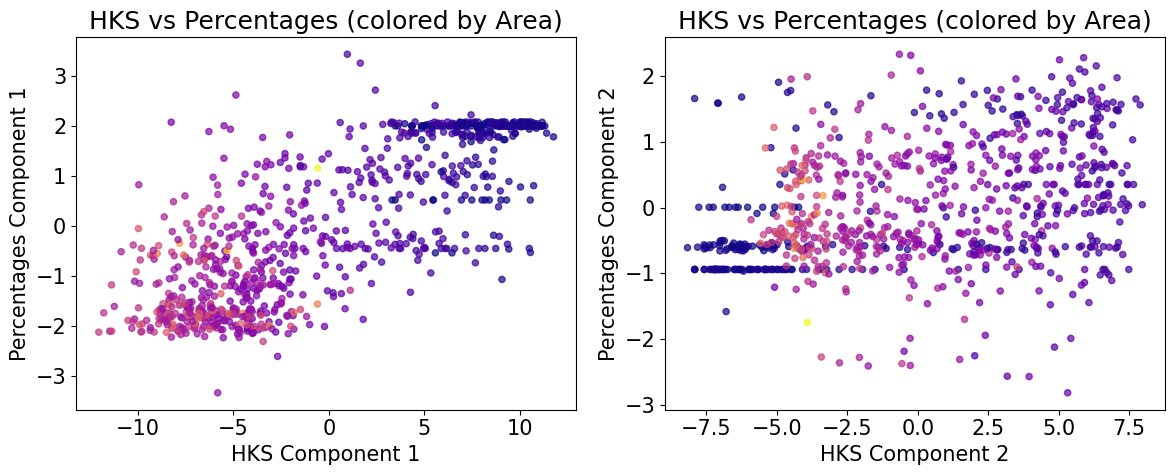

In [363]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, scores, label in zip(axes, [X_c, Y_c], ['HKS', 'Percentages']):
    sc = ax.scatter(scores[:, 0], scores[:, 1], c=filtered_areas, cmap='plasma', alpha=0.7, s=20)
    ax.set_title(f'PLS canonical scores — {label}')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    fig.colorbar(sc, ax=ax, label='Area')
plt.tight_layout()
plt.show()

# plot hks component 1 vs percentages component 1

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i in range(2): 
    axes[i].scatter(X_c[:, i], Y_c[:, i], c=filtered_areas, cmap='plasma', alpha=0.7, s=20)
    axes[i].set_xlabel(f'HKS Component {i+1}')
    axes[i].set_ylabel(f'Percentages Component {i+1}')
    axes[i].set_title(f'HKS vs Percentages (colored by Area)')
plt.tight_layout()
plt.show()



In [364]:

X  = np.concatenate((hks_power_spectrum.reshape(hks_power_spectrum.shape[0], -1), percentages_normalised), axis=1) 
print(X.shape, percentages_normalised.shape[-1], hks_power_spectrum.shape[1]*hks_power_spectrum.shape[2])

(850, 129) 9 120


In [369]:
hks = hks_power_spectrum.reshape(hks_power_spectrum.shape[0], -1)
print(hks.shape)
method = 'umap' 
if method == 'tsne':
    emb = TSNE(n_components=2, random_state=42)
    hks_emb = emb.fit_transform(hks)
elif method == 'umap':
    import umap 
    hks_emb = umap.UMAP(n_components=2, random_state=42, n_neighbors=10, min_dist=1).fit_transform(hks)
elif method == 'phate':
    hks_emb = phate.PHATE(n_components=2, random_state=42, knn=5, t=10, gamma=0).fit_transform(hks)
elif method == 'pca':
    hks_emb = PCA(n_components=2).fit_transform(hks)



(850, 120)


/opt/homebrew/anaconda3/envs/scmpx/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


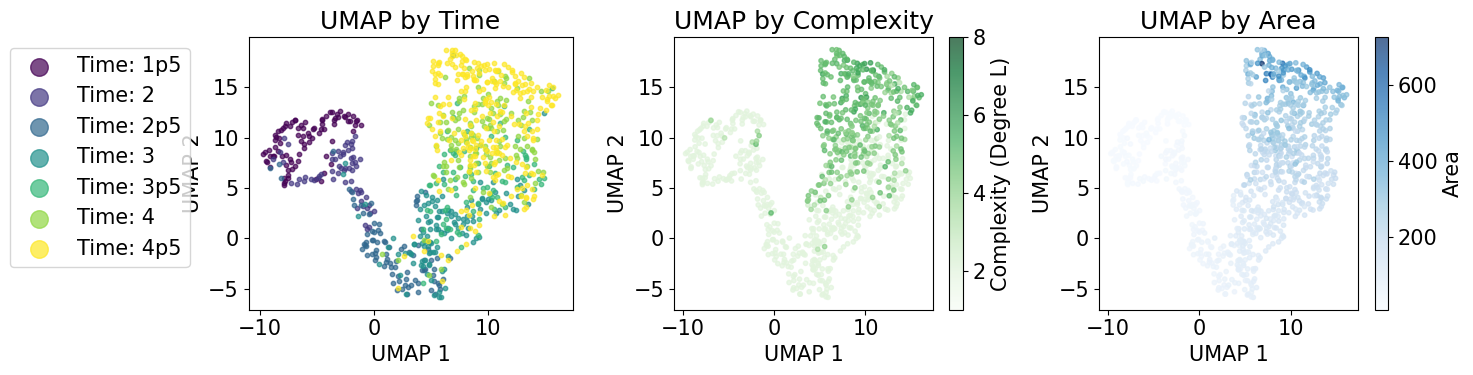

In [370]:
# Figure 1: Time and Complexity
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
point_size = 10

cmap_time = plt.get_cmap('viridis')
for i, t in enumerate(unique_times):
    mask = filtered_times == t
    color = cmap_time(i / (len(unique_times) - 1))
    axes[0].scatter(hks_emb[mask, 0], hks_emb[mask, 1], color=color, alpha=0.7, s=point_size, label=f"Time: {t}")
axes[0].set_title(f'{method.upper()} by Time')
axes[0].set_xlabel(f'{method.upper()} 1')
axes[0].set_ylabel(f'{method.upper()} 2')
axes[0].legend(bbox_to_anchor=(-0.15, 1), loc='upper right', markerscale=4)

sc = axes[1].scatter(hks_emb[:, 0], hks_emb[:, 1], c=l_cross_values, cmap='Greens', alpha=0.7, s=point_size, vmin=1, vmax=8)
axes[1].set_title(f'{method.upper()} by Complexity')
axes[1].set_xlabel(f'{method.upper()} 1')
axes[1].set_ylabel(f'{method.upper()} 2')
fig.colorbar(sc, ax=axes[1], label='Complexity (Degree L)')

sc = axes[2].scatter(hks_emb[:, 0], hks_emb[:, 1], c=filtered_areas, cmap='Blues', alpha=0.7, s=point_size)
axes[2].set_title(f'{method.upper()} by Area')
axes[2].set_xlabel(f'{method.upper()} 1')
axes[2].set_ylabel(f'{method.upper()} 2')
fig.colorbar(sc, ax=axes[2], label='Area')

plt.tight_layout()
plt.show()

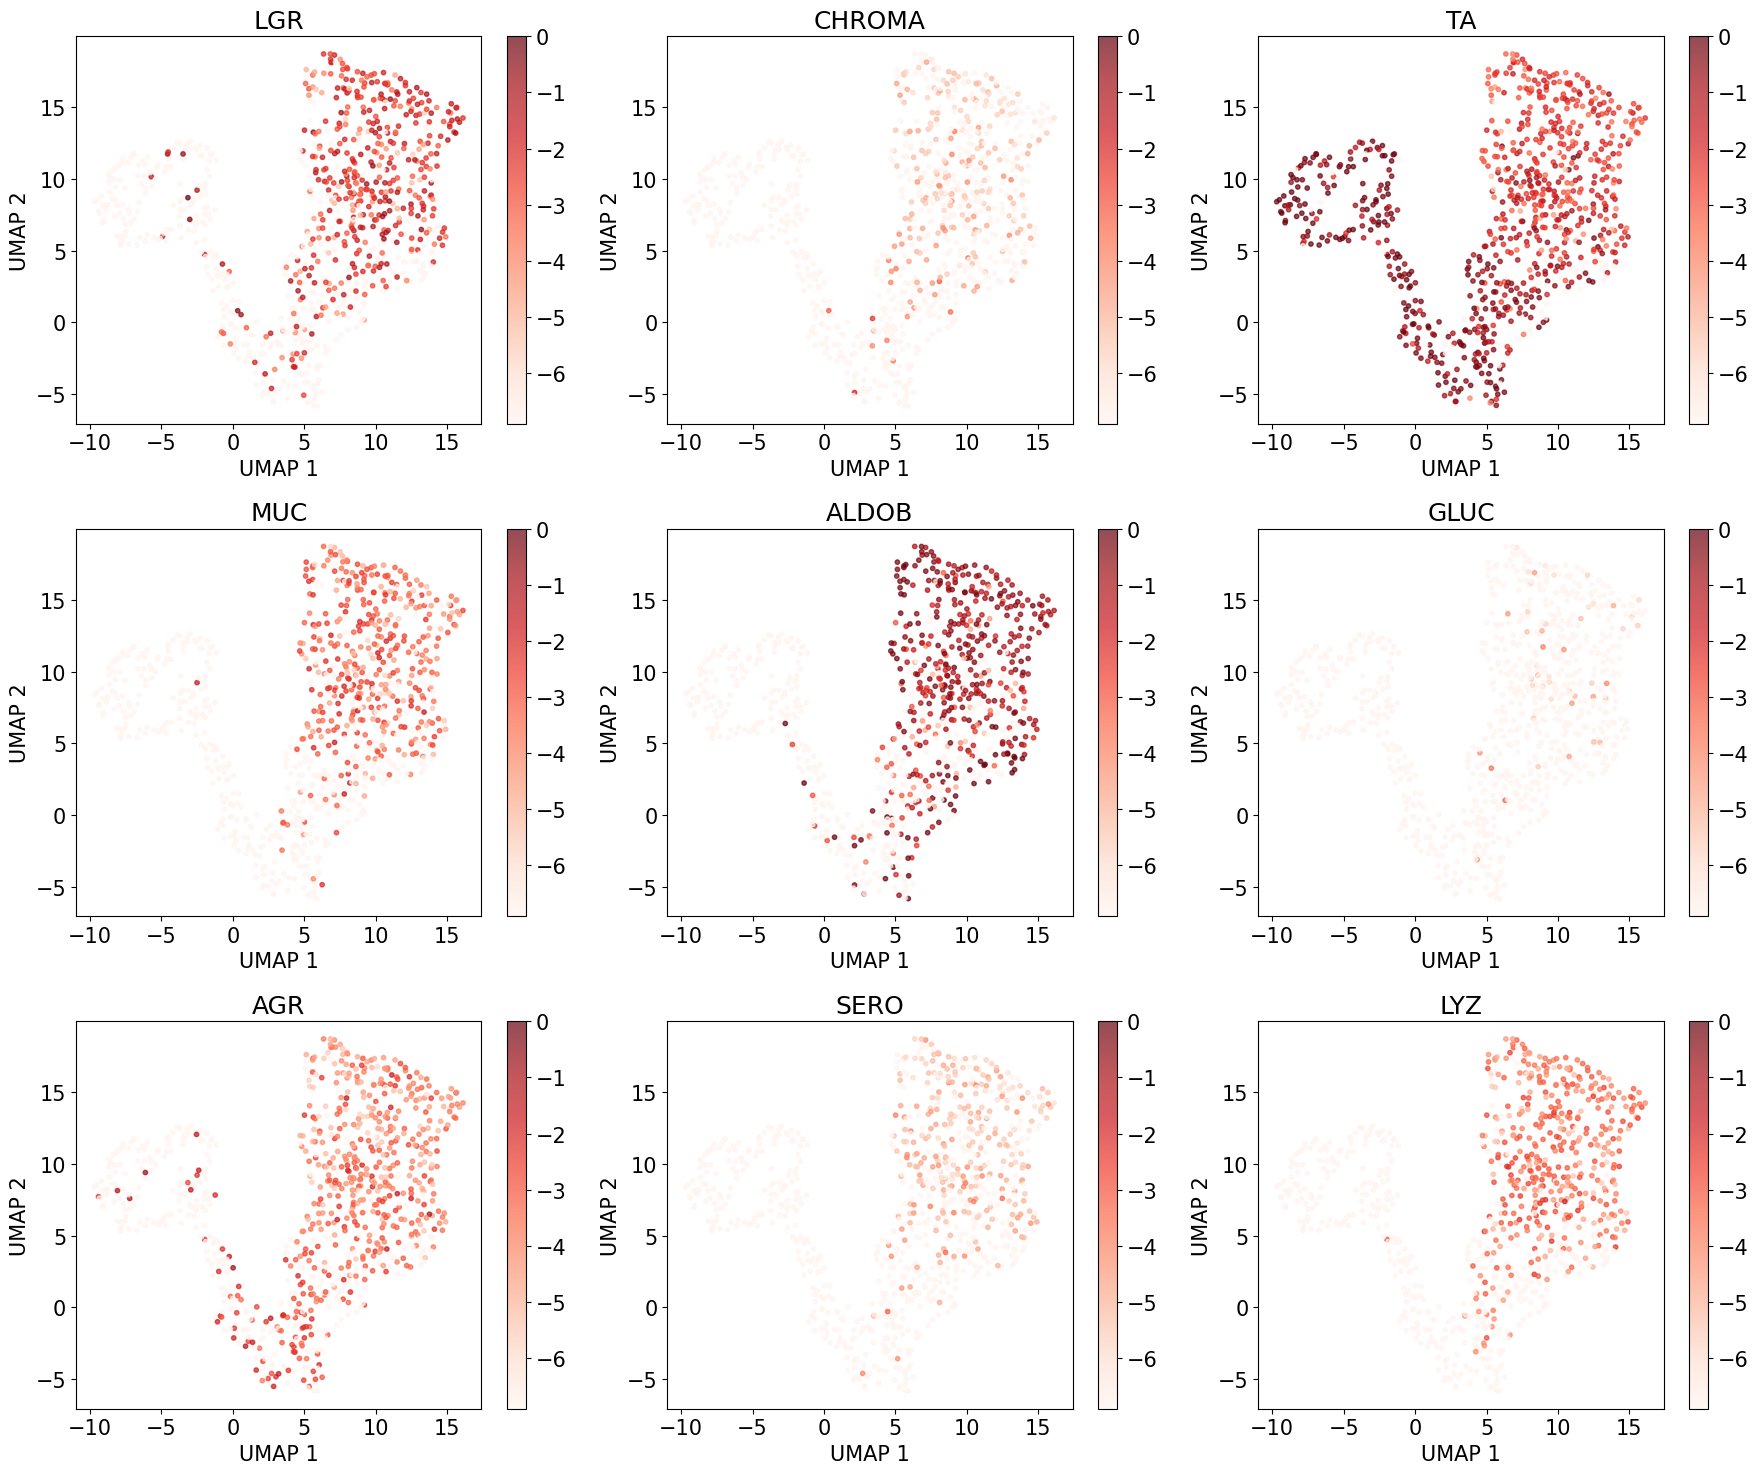

In [372]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

vmin = np.log(percentages_full + 1e-3).min()
vmax = np.log(percentages_full + 1e-3).max()

for i in range(percentages_full.shape[1]-1):
    sc = axes[i].scatter(hks_emb[:, 0], hks_emb[:, 1], c=np.log(percentages_full[:, i]+1e-3), cmap='Reds', alpha=0.7, s=point_size, vmin=vmin, vmax=vmax)
    axes[i].set_title(col_names[i])
    axes[i].set_xlabel(f'{method.upper()} 1')
    axes[i].set_ylabel(f'{method.upper()} 2')
    fig.colorbar(sc, ax=axes[i])

plt.tight_layout()
plt.show()

In [380]:
X  = np.concatenate((hks_power_spectrum.reshape(hks_power_spectrum.shape[0], -1), percentages_normalised), axis=1) 
print(X.shape, percentages_normalised.shape[-1], hks_power_spectrum.shape[1]*hks_power_spectrum.shape[2])

method = 'umap' 
if method == 'tsne':
    emb = TSNE(n_components=2, random_state=42)
    X_emb = emb.fit_transform(X)
elif method == 'umap':
    X_emb = umap.UMAP(n_components=2, random_state=12, n_neighbors=20, min_dist=1).fit_transform(X)
elif method == 'phate':
    X_emb = phate.PHATE(n_components=2, random_state=42, knn=50, t=30).fit_transform(X)
elif method == 'pca':
    X_emb = PCA(n_components=2).fit_transform(X)

(850, 129) 9 120


/opt/homebrew/anaconda3/envs/scmpx/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


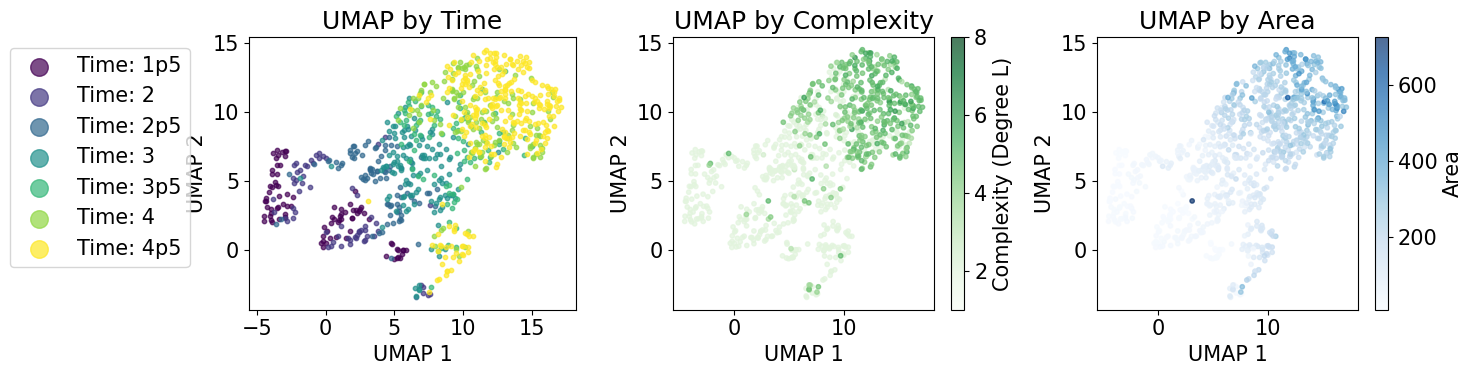

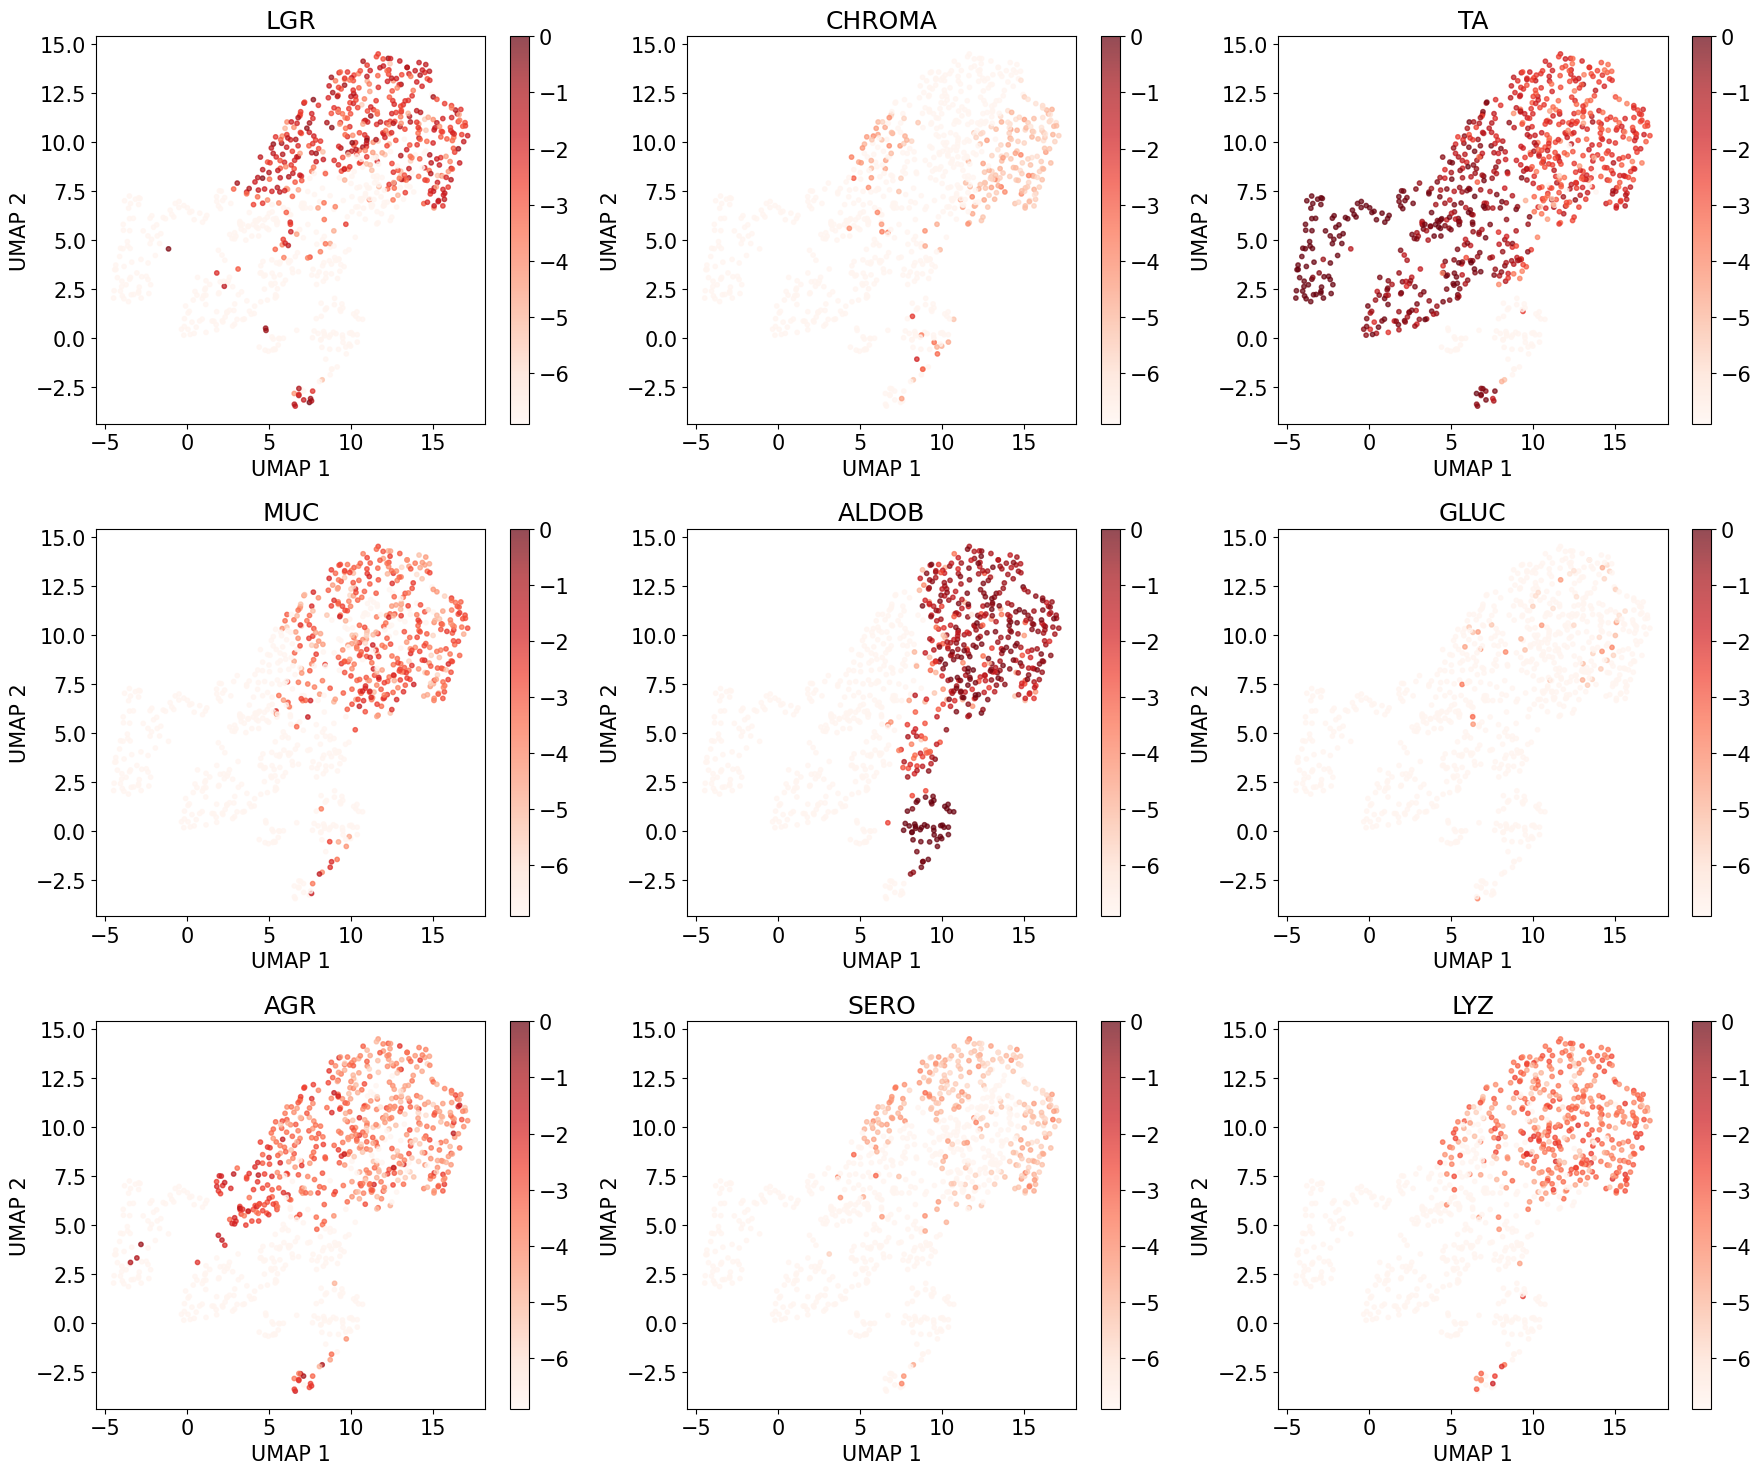

In [381]:
col_names = fate_names 
unique_times = np.unique(filtered_times)
point_size = 10

# Figure 1: Time and Complexity
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

cmap_time = plt.get_cmap('viridis')
for i, t in enumerate(unique_times):
    mask = filtered_times == t
    color = cmap_time(i / (len(unique_times) - 1))
    axes[0].scatter(X_emb[mask, 0], X_emb[mask, 1], color=color, alpha=0.7, s=point_size, label=f"Time: {t}")
axes[0].set_title(f'{method.upper()} by Time')
axes[0].set_xlabel(f'{method.upper()} 1')
axes[0].set_ylabel(f'{method.upper()} 2')
axes[0].legend(bbox_to_anchor=(-0.15, 1), loc='upper right', markerscale=4)

sc = axes[1].scatter(X_emb[:, 0], X_emb[:, 1], c=l_cross_values, cmap='Greens', alpha=0.7, s=point_size, vmin=1, vmax=8)
axes[1].set_title(f'{method.upper()} by Complexity')
axes[1].set_xlabel(f'{method.upper()} 1')
axes[1].set_ylabel(f'{method.upper()} 2')
fig.colorbar(sc, ax=axes[1], label='Complexity (Degree L)')

sc = axes[2].scatter(X_emb[:, 0], X_emb[:, 1], c=filtered_areas, cmap='Blues', alpha=0.7, s=point_size)
axes[2].set_title(f'{method.upper()} by Area')
axes[2].set_xlabel(f'{method.upper()} 1')
axes[2].set_ylabel(f'{method.upper()} 2')
fig.colorbar(sc, ax=axes[2], label='Area')

plt.tight_layout()
plt.show()

# Figure 2: Fate marker percentages (3x3)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.flatten()

vmin = np.log(percentages_full + 1e-3).min()
vmax = np.log(percentages_full + 1e-3).max()

for i in range(percentages_full.shape[1]-1):
    sc = axes[i].scatter(X_emb[:, 0], X_emb[:, 1], c=np.log(percentages_full[:, i]+1e-3), cmap='Reds', alpha=0.7, s=point_size, vmin=vmin, vmax=vmax)
    axes[i].set_title(col_names[i])
    axes[i].set_xlabel(f'{method.upper()} 1')
    axes[i].set_ylabel(f'{method.upper()} 2')
    fig.colorbar(sc, ax=axes[i])

plt.tight_layout()
plt.show()